# Adaptive Binning via 1-D Clustering of m/z Peaks

In Notebook 02 we binned spectra into **uniform** 0.01 Da bins. That gives ~88,000 dimensions regardless of where peaks actually appear. An alternative idea: let the **data** decide where the bin boundaries should be.

Here we pool all observed MS2 peak positions (top 200 most intense per spectrum) in the **300–400 m/z** range, then run **1-D k-means** with varying *k* to find natural clusters along the m/z axis. Each cluster center defines a bin, and the boundaries sit halfway between neighbouring centers.

We compare k = 300 / 1,000 / 3,000 / 10,000 and visualise the bins in a narrow m/z window (350–360).

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from pyteomics import mzml
from sklearn.cluster import MiniBatchKMeans
import warnings
warnings.filterwarnings('ignore', category=FutureWarning)

## 1. Load all MS2 spectra and extract the top-200 most intense peaks

In [ ]:
MZML_PATH = '04-17-23_CA_Tryp_HCD_10min_CLEAN.mzML'
TOP_N = 200  # keep the N most intense peaks per spectrum
MZ_RANGE = (300.0, 400.0)  # only cluster peaks in this m/z range

all_mz = []       # pooled m/z values (one entry per kept peak)
all_intensity = [] # corresponding intensities
n_spectra = 0

with mzml.read(MZML_PATH) as reader:
    for spectrum in reader:
        if spectrum.get('ms level', 0) != 2:
            continue
        mz_arr = spectrum['m/z array']
        int_arr = spectrum['intensity array']

        # Keep only the top-N most intense peaks
        if len(mz_arr) > TOP_N:
            top_idx = np.argpartition(int_arr, -TOP_N)[-TOP_N:]
            mz_arr = mz_arr[top_idx]
            int_arr = int_arr[top_idx]

        # Filter to the m/z range of interest
        range_mask = (mz_arr >= MZ_RANGE[0]) & (mz_arr <= MZ_RANGE[1])
        mz_arr = mz_arr[range_mask]
        int_arr = int_arr[range_mask]

        if len(mz_arr) > 0:
            all_mz.append(mz_arr)
            all_intensity.append(int_arr)
        n_spectra += 1

all_mz = np.concatenate(all_mz)
all_intensity = np.concatenate(all_intensity)

print(f'Loaded {n_spectra} MS2 spectra')
print(f'Peaks in {MZ_RANGE[0]:.0f}–{MZ_RANGE[1]:.0f} m/z (top {TOP_N} per spectrum): {len(all_mz):,}')
print(f'm/z range: {all_mz.min():.2f} – {all_mz.max():.2f}')

## 2. 1-D k-means clustering

We reshape the pooled m/z values into a column vector and run `MiniBatchKMeans` (much faster than full k-means for large *n*) with k = 300 / 1,000 / 3,000 / 10,000.

In [ ]:
K_VALUES = [300, 1_000, 3_000, 10_000]

X = all_mz.reshape(-1, 1)  # sklearn expects 2-D input

results = {}  # k -> {centers, boundaries, labels}

for k in K_VALUES:
    print(f'Fitting k = {k:,} ...', end=' ', flush=True)
    km = MiniBatchKMeans(
        n_clusters=k,
        batch_size=max(1024, k * 3),
        random_state=42,
        n_init=3,
    )
    labels = km.fit_predict(X)
    centers = np.sort(km.cluster_centers_.ravel())
    # Bin boundaries sit halfway between consecutive centers
    boundaries = (centers[:-1] + centers[1:]) / 2.0
    results[k] = dict(centers=centers, boundaries=boundaries, labels=labels, model=km)
    print(f'done  (inertia={km.inertia_:.2f})')

print('\nAll fits complete.')

Fitting k = 300 ... done  (inertia=18.12)
Fitting k = 1,000 ... 

## 3. Visualise bins in the 350–360 m/z window

For each *k* we:
1. Draw the bin boundaries as vertical dashed lines.
2. Plot the actual peaks (as stems) that fall in this window.
3. Colour-code peaks by their assigned bin so you can see how the clustering groups nearby peaks.

In [40]:
MZ_LO, MZ_HI = 355.0, 358.0

# Mask for peaks in the window
window_mask = (all_mz >= MZ_LO) & (all_mz <= MZ_HI)
win_mz = all_mz[window_mask]
win_int = all_intensity[window_mask]

# Normalise intensities for plotting
if win_int.max() > 0:
    win_int_norm = win_int / win_int.max()
else:
    win_int_norm = win_int

print(f'Peaks in [{MZ_LO}, {MZ_HI}] window: {len(win_mz)}')

Peaks in [355.0, 358.0] window: 323


KeyError: 3000

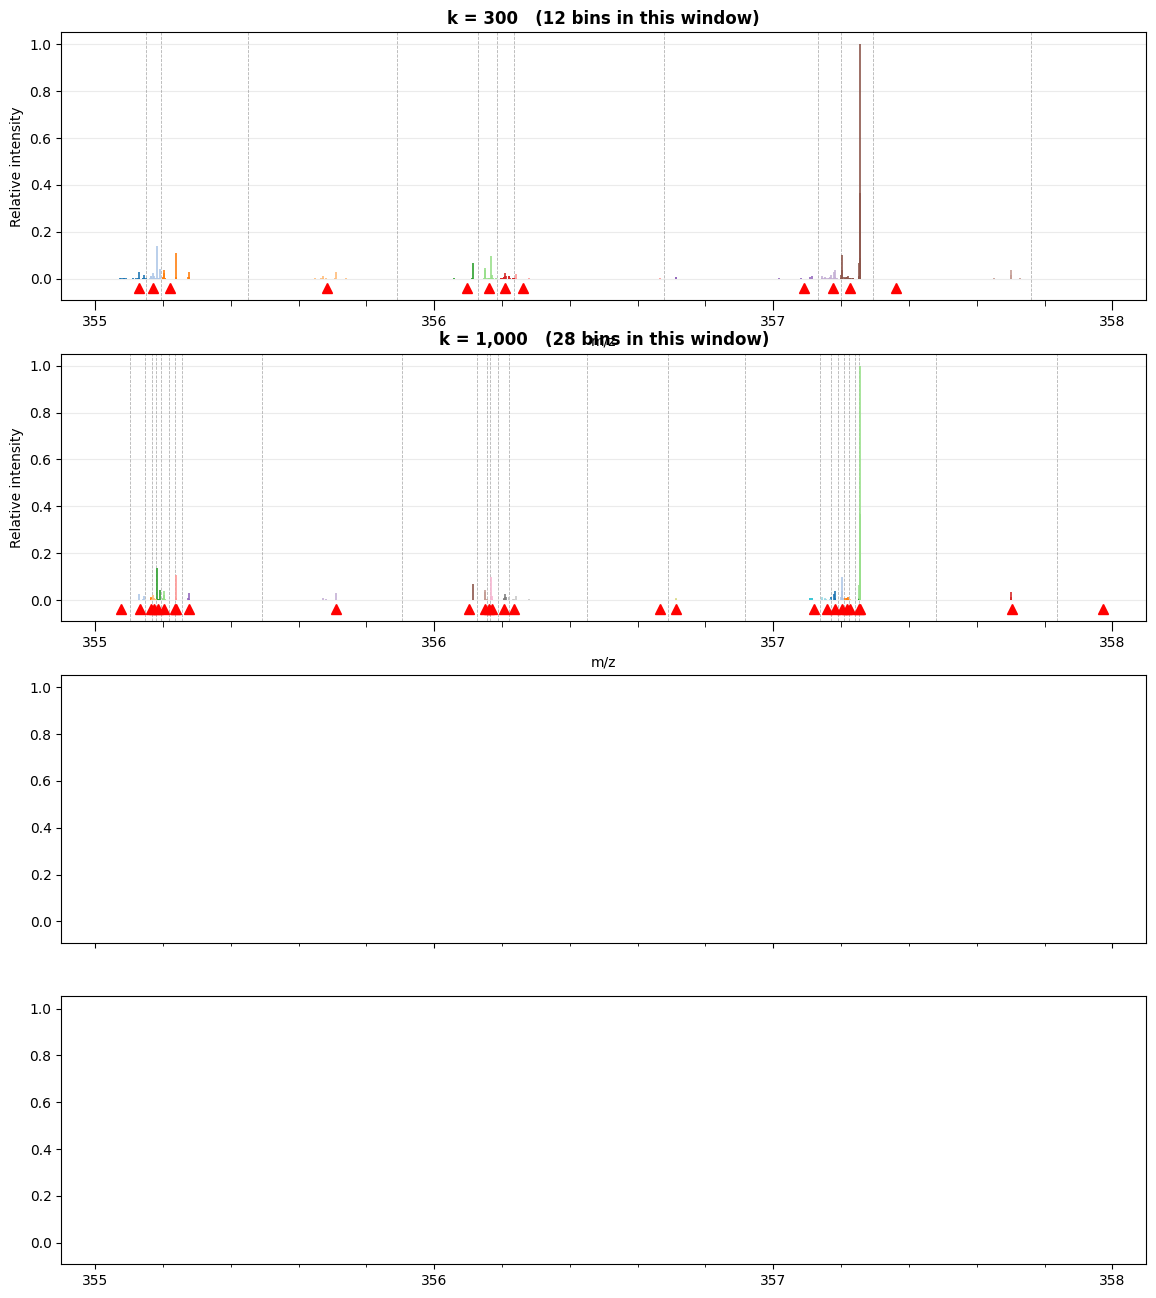

In [41]:
from matplotlib.ticker import MultipleLocator

fig, axes = plt.subplots(len(K_VALUES), 1, figsize=(14, 4 * len(K_VALUES)),
                         sharex=True, sharey=True)

# Build a colour cycle
cmap = plt.cm.tab20

for ax, k in zip(axes, K_VALUES):
    res = results[k]
    centers = res['centers']
    boundaries = res['boundaries']

    # Boundaries inside the window
    b_in = boundaries[(boundaries >= MZ_LO) & (boundaries <= MZ_HI)]
    # Centers inside the window
    c_in = centers[(centers >= MZ_LO) & (centers <= MZ_HI)]

    # Assign each peak in the window to its nearest center
    if len(win_mz) > 0 and len(centers) > 0:
        # Use searchsorted for fast nearest-center lookup
        insert_idx = np.searchsorted(centers, win_mz)
        # Clamp to valid range
        insert_idx = np.clip(insert_idx, 1, len(centers) - 1)
        # Pick whichever neighbour is closer
        left_dist = np.abs(win_mz - centers[insert_idx - 1])
        right_dist = np.abs(win_mz - centers[insert_idx])
        nearest = np.where(left_dist < right_dist, insert_idx - 1, insert_idx)
        # Map global center index to a local colour index
        unique_bins = np.unique(nearest)
        bin_to_colour = {b: i for i, b in enumerate(unique_bins)}
        colours = [cmap(bin_to_colour[b] % 20) for b in nearest]
    else:
        colours = None

    # Draw bin boundaries
    for b in b_in:
        ax.axvline(b, color='grey', linewidth=0.6, linestyle='--', alpha=0.6)

    # Draw peaks as stems
    markerline, stemlines, baseline = ax.stem(
        win_mz, win_int_norm, linefmt='-', markerfmt=' ', basefmt=' ',
    )
    # Colour each stem individually via the LineCollection API
    # (newer matplotlib returns a LineCollection, not a list of Line2D)
    if colours is not None:
        stemlines.set_colors(colours)
        stemlines.set_linewidths(1.2)

    # Mark cluster centers
    ax.plot(c_in, np.full_like(c_in, -0.04), marker='^', color='red',
            linestyle='none', markersize=7, zorder=5, clip_on=False)

    n_bins_window = len(c_in)
    ax.set_ylabel('Relative intensity')
    ax.set_xlabel('m/z')
    ax.set_title(f'k = {k:,}   ({n_bins_window} bins in this window)',
                 fontsize=12, fontweight='bold')
    ax.set_xlim(MZ_LO - 0.1, MZ_HI + 0.1)
    # Minor ticks every 0.2 (no labels), major ticks every 1.0 (with labels)
    ax.xaxis.set_major_locator(MultipleLocator(1.0))
    ax.xaxis.set_minor_locator(MultipleLocator(0.2))
    ax.tick_params(axis='x', which='minor', length=4)
    ax.tick_params(axis='x', which='major', length=7, labelbottom=True)
    ax.grid(axis='y', alpha=0.25)

# Legend
boundary_patch = plt.Line2D([0], [0], color='grey', linestyle='--', linewidth=0.8,
                            label='Bin boundary')
center_patch = plt.Line2D([0], [0], marker='^', color='red', linestyle='none',
                          markersize=7, label='Cluster center')
axes[0].legend(handles=[boundary_patch, center_patch], loc='upper right')

fig.suptitle('Adaptive Binning via 1-D k-means (m/z 355–358)',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## 4. Summary statistics

How wide are the bins for each *k*? Let's look at the distribution of bin widths (distance between consecutive boundaries).

In [ ]:
fig, axes = plt.subplots(1, len(K_VALUES), figsize=(4 * len(K_VALUES), 3.5),
                         sharey=False)

for ax, k in zip(axes, K_VALUES):
    boundaries = results[k]['boundaries']
    # Bin widths = gaps between consecutive boundaries
    widths = np.diff(boundaries)
    ax.hist(widths, bins=60, color='steelblue', edgecolor='black', alpha=0.8)
    ax.axvline(np.median(widths), color='red', linestyle='--',
               label=f'median = {np.median(widths):.3f} Da')
    ax.set_title(f'k = {k:,}', fontweight='bold')
    ax.set_xlabel('Bin width (Da)')
    ax.legend(fontsize=8)
    ax.grid(axis='y', alpha=0.25)

axes[0].set_ylabel('Count')
fig.suptitle('Distribution of adaptive bin widths', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
print(f'{"k":>8}  {"Median bin width (Da)":>22}  {"Mean bin width (Da)":>20}  {"Min":>8}  {"Max":>8}')
print('-' * 75)
for k in K_VALUES:
    widths = np.diff(results[k]['boundaries'])
    print(f'{k:>8,}  {np.median(widths):>22.4f}  {np.mean(widths):>20.4f}  {widths.min():>8.4f}  {widths.max():>8.4f}')

## 5. Observations

- With **k = 300**, bins are very wide (~0.33 Da each across the 100 Da range) and many distinct peaks get lumped together.
- **k = 1,000** gives ~0.1 Da median bin width and begins to separate peaks, but still has collisions in dense m/z regions.
- **k = 3,000** provides ~0.03 Da resolution, approaching the precision of fine uniform bins but adapting to where peaks actually occur.
- **k = 10,000** gives very fine resolution across the 100 Da window — comparable to 0.01 Da uniform bins, but concentrated where the data lives.

Adaptive binning concentrates resolution where the data actually lives, which can be a more efficient representation than uniform bins for downstream ML tasks.

In [ ]:
print(f'{"Bandwidth (Da)":>15}  {"# Bins":>8}  {"Median width (Da)":>18}  {"Mean width (Da)":>16}  {"Min":>8}  {"Max":>8}')
print('-' * 82)
for bw in BANDWIDTHS:
    res = kde_results[bw]
    if len(res['boundaries']) > 1:
        widths = np.diff(res['boundaries'])
        print(f'{bw:>15.2f}  {res["n_bins"]:>8,}  {np.median(widths):>18.4f}  {np.mean(widths):>16.4f}  {widths.min():>8.4f}  {widths.max():>8.4f}')
    else:
        print(f'{bw:>15.2f}  {res["n_bins"]:>8,}  {"(single bin)":>18}')

### 6.3 KDE bin width statistics

In [ ]:
fig, axes = plt.subplots(len(BANDWIDTHS), 1, figsize=(14, 4 * len(BANDWIDTHS)),
                         sharex=True, sharey=True)

cmap = plt.cm.tab20

for ax, bw in zip(axes, BANDWIDTHS):
    res = kde_results[bw]
    centers = res['centers']
    boundaries = res['boundaries']

    # Boundaries and centers inside the window
    b_in = boundaries[(boundaries >= MZ_LO) & (boundaries <= MZ_HI)]
    c_in = centers[(centers >= MZ_LO) & (centers <= MZ_HI)]

    # Assign each peak in the window to its nearest center
    if len(win_mz) > 0 and len(centers) > 0:
        insert_idx = np.searchsorted(centers, win_mz)
        insert_idx = np.clip(insert_idx, 1, len(centers) - 1)
        left_dist = np.abs(win_mz - centers[insert_idx - 1])
        right_dist = np.abs(win_mz - centers[insert_idx])
        nearest = np.where(left_dist < right_dist, insert_idx - 1, insert_idx)
        unique_bins = np.unique(nearest)
        bin_to_colour = {b: i for i, b in enumerate(unique_bins)}
        colours = [cmap(bin_to_colour[b] % 20) for b in nearest]
    else:
        colours = None

    # Draw bin boundaries
    for b in b_in:
        ax.axvline(b, color='grey', linewidth=0.6, linestyle='--', alpha=0.6)

    # Draw peaks as stems
    markerline, stemlines, baseline = ax.stem(
        win_mz, win_int_norm, linefmt='-', markerfmt=' ', basefmt=' ',
    )
    if colours is not None:
        stemlines.set_colors(colours)
        stemlines.set_linewidths(1.2)

    # Mark cluster centers
    ax.plot(c_in, np.full_like(c_in, -0.04), marker='^', color='red',
            linestyle='none', markersize=7, zorder=5, clip_on=False)

    n_bins_window = len(c_in)
    ax.set_ylabel('Relative intensity')
    ax.set_xlabel('m/z')
    ax.set_title(f'bandwidth = {bw} Da   ({n_bins_window} bins in this window)',
                 fontsize=12, fontweight='bold')
    ax.set_xlim(MZ_LO - 0.1, MZ_HI + 0.1)
    ax.xaxis.set_major_locator(MultipleLocator(1.0))
    ax.xaxis.set_minor_locator(MultipleLocator(0.2))
    ax.tick_params(axis='x', which='minor', length=4)
    ax.tick_params(axis='x', which='major', length=7, labelbottom=True)
    ax.grid(axis='y', alpha=0.25)

# Legend
boundary_patch = plt.Line2D([0], [0], color='grey', linestyle='--', linewidth=0.8,
                            label='Bin boundary')
center_patch = plt.Line2D([0], [0], marker='^', color='red', linestyle='none',
                          markersize=7, label='Bin center')
axes[0].legend(handles=[boundary_patch, center_patch], loc='upper right')

fig.suptitle(f'KDE-based Bins with Peaks (m/z {MZ_LO:.0f}–{MZ_HI:.0f}, min distance = {MIN_DISTANCE_DA} Da)',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

### 6.2 KDE bins with actual peaks (355–358 m/z)

Same view as the k-means plots: peaks are colour-coded by their assigned bin, boundaries are grey dashed lines, bin centers are red triangles.

In [ ]:
from matplotlib.ticker import MultipleLocator

fig, axes = plt.subplots(len(BANDWIDTHS), 1, figsize=(14, 4 * len(BANDWIDTHS)),
                         sharex=True)

grid_mask = (grid >= MZ_LO) & (grid <= MZ_HI)
grid_win = grid[grid_mask]

for ax, bw in zip(axes, BANDWIDTHS):
    res = kde_results[bw]
    centers = res['centers']
    boundaries = res['boundaries']
    density = res['density']

    # KDE density in the window
    density_win = density[grid_mask]

    # Centers and boundaries in the window
    c_in = centers[(centers >= MZ_LO) & (centers <= MZ_HI)]
    b_in = boundaries[(boundaries >= MZ_LO) & (boundaries <= MZ_HI)]

    # Plot the KDE density curve
    ax.plot(grid_win, density_win, color='steelblue', linewidth=1.5, label='KDE density')

    # Draw bin boundaries
    for b in b_in:
        ax.axvline(b, color='grey', linewidth=0.6, linestyle='--', alpha=0.6)

    # Mark cluster centers on the density curve
    c_density = np.interp(c_in, grid, density)
    ax.plot(c_in, c_density, marker='v', color='red',
            linestyle='none', markersize=7, zorder=5, label='Bin center')

    n_bins_window = len(c_in)
    ax.set_ylabel('Density')
    ax.set_xlabel('m/z')
    ax.set_title(f'bandwidth = {bw} Da   ({res["n_bins"]} total bins, {n_bins_window} in this window)',
                 fontsize=12, fontweight='bold')
    ax.set_xlim(MZ_LO - 0.1, MZ_HI + 0.1)
    ax.xaxis.set_major_locator(MultipleLocator(1.0))
    ax.xaxis.set_minor_locator(MultipleLocator(0.2))
    ax.tick_params(axis='x', which='minor', length=4)
    ax.tick_params(axis='x', which='major', length=7, labelbottom=True)
    ax.grid(axis='y', alpha=0.25)

axes[0].legend(loc='upper right')

fig.suptitle(f'KDE-based Adaptive Binning (m/z {MZ_LO:.0f}–{MZ_HI:.0f}, min distance = {MIN_DISTANCE_DA} Da)',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

### 6.1 KDE density curves in the 355–358 m/z window

Each subplot shows the estimated peak density (blue curve), the detected bin centers (red triangles), and bin boundaries (grey dashed lines). Narrower bandwidths resolve finer structure but produce more bins.

In [ ]:
from scipy.signal import find_peaks
from scipy.stats import gaussian_kde

# Evaluate KDE on a fine grid spanning the full m/z range
grid = np.linspace(all_mz.min(), all_mz.max(), 100_000)

# Bandwidth values to compare (in Da, used as the KDE bandwidth factor)
BANDWIDTHS = [0.5, 0.1, 0.05, 0.01]
MIN_DISTANCE_DA = 0.01  # minimum distance between bin centers (in Da)

# Convert min distance from Da to grid indices
grid_step = grid[1] - grid[0]
min_dist_idx = max(1, int(MIN_DISTANCE_DA / grid_step))

kde_results = {}  # bandwidth -> {centers, boundaries, density, n_bins}

for bw in BANDWIDTHS:
    print(f'KDE bandwidth = {bw} Da ...', end=' ', flush=True)

    # Fit KDE with specified bandwidth
    kde = gaussian_kde(all_mz, bw_method=bw / all_mz.std())
    density = kde(grid)

    # Find local maxima of the density with minimum distance constraint
    peak_indices, properties = find_peaks(density, distance=min_dist_idx)
    centers = grid[peak_indices]

    # Bin boundaries at midpoints between consecutive centers
    boundaries = (centers[:-1] + centers[1:]) / 2.0

    kde_results[bw] = dict(
        centers=centers,
        boundaries=boundaries,
        density=density,
        n_bins=len(centers),
    )
    print(f'{len(centers)} bins found')

print('\nAll KDE fits complete.')

## 6. Alternative: KDE-based adaptive binning

Instead of choosing *k* up front, we can let the data speak for itself using **Kernel Density Estimation (KDE)**:

1. Estimate the density of observed m/z peaks using a Gaussian kernel.
2. Find **local maxima** (modes) of the density — these are natural bin centers where peaks concentrate.
3. Place **bin boundaries** at the midpoints between consecutive centers.

The two key parameters are:
- **Bandwidth** — controls smoothing of the KDE. Smaller bandwidth = more peaks found = finer bins.
- **`distance`** — minimum separation (in Da) between detected peaks. This directly enforces a floor on bin width, preventing two bins from being closer than this value.

We'll try several bandwidth values and a fixed minimum distance to see how resolution changes.

## 7. Similarity Preservation Evaluation

The whole point of binning is to discretise the m/z axis for downstream processing. But how much information do we lose? If two spectra are similar in the original (continuous) representation, do they stay similar after binning?

To answer this we:
1. Load individual spectra (not pooled) so we can compute **pairwise** cosine similarities.
2. Use **fine uniform bins (0.01 Da)** as the ground truth — the same baseline from Notebook 02.
3. Bin each spectrum under every strategy (uniform, k-means, KDE) and compute pairwise similarities.
4. Correlate each strategy's similarities against the ground truth (Pearson *r*, MAE).

In [ ]:
from util import get_all_MS2_objects

# Load individual spectra (we need per-spectrum mz/intensity for pairwise comparison)
spectra = get_all_MS2_objects(MZML_PATH, max_spectra=200)

# For each spectrum, keep top-N peaks and filter to MZ_RANGE (matching earlier cells)
spectra_mz = []
spectra_int = []

for spec in spectra:
    mz_arr = np.array(spec.mz)
    int_arr = np.array(spec.intensity)

    # Keep top-N most intense peaks
    if len(mz_arr) > TOP_N:
        top_idx = np.argpartition(int_arr, -TOP_N)[-TOP_N:]
        mz_arr = mz_arr[top_idx]
        int_arr = int_arr[top_idx]

    # Filter to m/z range
    mask = (mz_arr >= MZ_RANGE[0]) & (mz_arr <= MZ_RANGE[1])
    mz_arr = mz_arr[mask]
    int_arr = int_arr[mask]

    spectra_mz.append(mz_arr)
    spectra_int.append(int_arr)

n_eval = len(spectra_mz)
print(f'Loaded {n_eval} spectra for similarity evaluation')
print(f'Peaks per spectrum (in {MZ_RANGE[0]:.0f}–{MZ_RANGE[1]:.0f} m/z): '
      f'min={min(len(m) for m in spectra_mz)}, '
      f'max={max(len(m) for m in spectra_mz)}, '
      f'median={np.median([len(m) for m in spectra_mz]):.0f}')

In [ ]:
from scipy.spatial.distance import pdist, squareform


def bin_spectrum_uniform(mz, intensity, bin_width, mz_range):
    """Bin a spectrum into uniform-width bins. Returns a dense vector."""
    n_bins = int((mz_range[1] - mz_range[0]) / bin_width) + 1
    vec = np.zeros(n_bins)
    for m, i in zip(mz, intensity):
        idx = int((m - mz_range[0]) / bin_width)
        idx = min(idx, n_bins - 1)
        vec[idx] += i
    return vec


def bin_spectrum_adaptive(mz, intensity, centers):
    """Bin a spectrum using pre-computed sorted centers (k-means or KDE).
    Each peak is assigned to its nearest center; intensities are summed per bin.
    Returns a dense vector of length len(centers)."""
    vec = np.zeros(len(centers))
    if len(mz) == 0 or len(centers) == 0:
        return vec
    insert_idx = np.searchsorted(centers, mz)
    insert_idx = np.clip(insert_idx, 1, len(centers) - 1)
    left_dist = np.abs(mz - centers[insert_idx - 1])
    right_dist = np.abs(mz - centers[insert_idx])
    nearest = np.where(left_dist < right_dist, insert_idx - 1, insert_idx)
    for bin_idx, i in zip(nearest, intensity):
        vec[bin_idx] += i
    return vec


def pairwise_cosine_sim(vectors):
    """Compute pairwise cosine similarities (upper triangle).
    Returns a 1-D array of similarity values."""
    # pdist returns 1 - cosine_similarity
    dists = pdist(vectors, metric='cosine')
    # Convert to similarity; handle NaN (from zero-norm vectors)
    sims = 1.0 - dists
    sims = np.nan_to_num(sims, nan=0.0)
    return sims


print('Helper functions defined.')

In [ ]:
# Build a vector matrix (n_spectra x n_bins) for each binning strategy

strategies = {}

# --- Uniform binning ---
for bin_width in [0.01, 0.1, 1.0]:
    name = f'uniform {bin_width} Da'
    vecs = np.array([bin_spectrum_uniform(m, i, bin_width, MZ_RANGE)
                     for m, i in zip(spectra_mz, spectra_int)])
    strategies[name] = vecs
    print(f'{name:25s}  →  {vecs.shape[1]:>6,} bins')

# --- K-means adaptive ---
for k in K_VALUES:
    name = f'k-means k={k:,}'
    centers = results[k]['centers']
    vecs = np.array([bin_spectrum_adaptive(m, i, centers)
                     for m, i in zip(spectra_mz, spectra_int)])
    strategies[name] = vecs
    print(f'{name:25s}  →  {vecs.shape[1]:>6,} bins')

# --- KDE adaptive ---
for bw in BANDWIDTHS:
    name = f'KDE bw={bw}'
    centers = kde_results[bw]['centers']
    vecs = np.array([bin_spectrum_adaptive(m, i, centers)
                     for m, i in zip(spectra_mz, spectra_int)])
    strategies[name] = vecs
    print(f'{name:25s}  →  {vecs.shape[1]:>6,} bins')

print(f'\n{len(strategies)} strategies built, each with {n_eval} spectra.')

In [ ]:
from scipy.stats import pearsonr

# Ground truth: uniform 0.01 Da
ground_truth_name = 'uniform 0.01 Da'
gt_sims = pairwise_cosine_sim(strategies[ground_truth_name])

# Evaluate every strategy against the ground truth
eval_results = {}

for name, vecs in strategies.items():
    sims = pairwise_cosine_sim(vecs)
    r, p = pearsonr(gt_sims, sims)
    mae = np.mean(np.abs(gt_sims - sims))
    median_ae = np.median(np.abs(gt_sims - sims))
    n_bins = vecs.shape[1]
    eval_results[name] = dict(sims=sims, r=r, p=p, mae=mae, median_ae=median_ae, n_bins=n_bins)

print('Pairwise similarities computed for all strategies.')

In [ ]:
# Scatter plots: ground truth similarity (x) vs strategy similarity (y)
# Skip the ground truth itself (it would just be a perfect diagonal)
plot_names = [name for name in strategies if name != ground_truth_name]

n_plots = len(plot_names)
n_cols = 4
n_rows = (n_plots + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(4.5 * n_cols, 4 * n_rows),
                         squeeze=False)

for idx, name in enumerate(plot_names):
    row, col = divmod(idx, n_cols)
    ax = axes[row][col]
    res = eval_results[name]

    # Subsample for plotting speed if many pairs
    sims = res['sims']
    if len(gt_sims) > 10_000:
        sample_idx = np.random.default_rng(42).choice(len(gt_sims), 10_000, replace=False)
        x, y = gt_sims[sample_idx], sims[sample_idx]
    else:
        x, y = gt_sims, sims

    ax.scatter(x, y, alpha=0.15, s=4, edgecolors='none', rasterized=True)
    ax.plot([0, 1], [0, 1], 'r--', linewidth=1, alpha=0.7)
    ax.set_xlim(-0.05, 1.05)
    ax.set_ylim(-0.05, 1.05)
    ax.set_aspect('equal')
    ax.set_title(f'{name}\nr={res["r"]:.4f}, MAE={res["mae"]:.4f}', fontsize=9)
    ax.set_xlabel('Ground truth sim', fontsize=8)
    ax.set_ylabel('Strategy sim', fontsize=8)
    ax.tick_params(labelsize=7)
    ax.grid(alpha=0.2)

# Hide unused subplots
for idx in range(n_plots, n_rows * n_cols):
    row, col = divmod(idx, n_cols)
    axes[row][col].set_visible(False)

fig.suptitle(f'Similarity Preservation: each strategy vs ground truth ({ground_truth_name})',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd

# Summary table
rows = []
for name in strategies:
    res = eval_results[name]
    rows.append({
        'Strategy': name,
        '# Bins': res['n_bins'],
        'Pearson r': res['r'],
        'MAE': res['mae'],
        'Median AE': res['median_ae'],
    })

summary_df = pd.DataFrame(rows).sort_values('Pearson r', ascending=False)
display(summary_df.style
    .format({'Pearson r': '{:.4f}', 'MAE': '{:.4f}', 'Median AE': '{:.4f}', '# Bins': '{:,}'})
    .background_gradient(subset=['Pearson r'], cmap='RdYlGn', vmin=0, vmax=1)
    .background_gradient(subset=['MAE'], cmap='RdYlGn_r', vmin=0)
    .set_caption('Similarity preservation vs ground truth (uniform 0.01 Da)')
)